In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.offsets import DateOffset
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
from fnmatch import fnmatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial.distance import cdist

In [2]:
#Function to select certain variables from files and concatenate
def process_daily_files(result_dir, files_to_open, variables_to_select, progress_bar=None):
    # Open the daily files as an xarray dataset
    ds = xr.open_mfdataset(str(result_dir / files_to_open), combine='nested')

    # Select specific variables
    ds = ds[variables_to_select]

    # Update progress bar
    if progress_bar:
        progress_bar.update(1)
    return ds

def plot_map_LCC(data, lat, lon, llim, ulim, units):
    #if you want to change the figure size of map projection you can do it here
    fig, ax = plt.subplots(figsize=(16, 9), subplot_kw=dict(projection=ccrs.LambertConformal()))
    #this is the actual plotting routine, using pcolormesh. Most variables are inputs from the function call
    im = ax.pcolormesh(lon,lat,data,cmap='Spectral_r',vmin=llim, vmax=ulim, transform=ccrs.PlateCarree())
    #this is for visualization of administrative boundaries. Many shapes included in the 'Natural Earth' library can also be used
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, edgecolor='#D3D3D3')
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(units)
    return fig, ax

In [3]:
result_dir = Path('/glade/derecho/scratch/demurray/archive/MUSICA_FCnudged30x8_20172018_082024/atm/hist')

files_to_open = 'MUSICA_FCnudged30x8_20172018_082024.cam.h0.*.nc'

variables_to_select = ['lat', 'lon', 'area','pom_a1SFWET', 'pom_a4SFWET', 'pom_c1SFWET', 'pom_c4SFWET', 
                       'soa1_a1SFWET', 'soa1_c1SFWET', 'soa1_a2SFWET', 'soa1_c2SFWET', 
                       'soa2_a1SFWET', 'soa2_c1SFWET', 'soa2_a2SFWET', 'soa2_c2SFWET', 
                       'soa3_a1SFWET', 'soa3_c1SFWET', 'soa3_a2SFWET',  'soa3_c2SFWET', 
                       'soa4_a1SFWET', 'soa4_c1SFWET', 'soa4_a2SFWET',  'soa4_c2SFWET', 
                       'soa5_a1SFWET', 'soa5_c1SFWET', 'soa5_a2SFWET',  'soa5_c2SFWET', 
                       'bc_a1SFWET', 'bc_a4SFWET', 'bc_c1SFWET', 'bc_c4SFWET', 'so4_a1SFWET', 
                       'so4_a2SFWET', 'so4_a3SFWET', 'so4_c1SFWET', 'so4_c2SFWET', 'so4_c3SFWET',
                       'WD_NH4', 'WD_HNO3', 'WD_NH3', 'PRECC', 'PRECL']

files_list = list(result_dir.glob(files_to_open))

# Initialize tqdm progress bar
progress = tqdm(total=len(files_list))

processed_data = []
for file in files_list:
    processed_data.append(process_daily_files(result_dir, file.relative_to(result_dir), variables_to_select, progress_bar=progress))

progress.close()

musica_daily = xr.concat(processed_data, dim='time').sortby('time')
musica_daily

100%|██████████| 729/729 [02:24<00:00,  5.05it/s]


<xarray.Dataset>
Dimensions:       (time: 729, ncol: 174098)
Coordinates:
  * time          (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
Dimensions without coordinates: ncol
Data variables: (12/42)
    lat           (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    lon           (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    area          (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_a1SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_a4SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_c1SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    ...            ...
    so4_c3SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_NH4        (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_HNO3       (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_NH3        (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    PRECC         (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    PRECL         (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
Attributes:
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              MUSICA_FCnudged30x8_20172018_082024
    logname:           demurray
    host:              derecho3
    initial_file:      /glade/derecho/scratch/demurray/inic/f.e22.FCnudged.ne...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [4]:
# Calculate SO4_wet_sum
nc_daily = musica_daily
nc_daily['SO4_wet_sum'] = (nc_daily['so4_a1SFWET'] + nc_daily['so4_a2SFWET'] + nc_daily['so4_a3SFWET'] 
                                + nc_daily['so4_c1SFWET'] + nc_daily['so4_c2SFWET'] + nc_daily['so4_c3SFWET']) * -1 * 0.843478

# Calculate NO3_wet
nc_daily['NO3_wet'] = nc_daily['WD_HNO3'] * -1 * 0.984006 #correct for HNO3 molar mass

# Calculate NH4_wet
nc_daily['WD_NH4_corr'] = nc_daily['WD_NH4'] * -1
nc_daily['WD_NH4_corr'] = nc_daily['WD_NH4_corr'].where(nc_daily['WD_NH4_corr'] != -0.0, 0.0)

# Calculate NH3_wet
nc_daily['WD_NH3_corr'] = nc_daily['WD_NH3'] * -1
nc_daily['WD_NH3_corr'] = nc_daily['WD_NH3_corr'].where(nc_daily['WD_NH3_corr'] != -0.0, 0.0)

nc_daily['WD_NH4_NH3_corr'] = nc_daily['WD_NH4_corr'] + nc_daily['WD_NH3_corr']

#Calculate total precipitation
nc_daily['PRECC_mm'] = nc_daily['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
nc_daily['PRECL_mm'] = nc_daily['PRECL']* (86400*1000)
nc_daily['PREC_tot_mm'] = nc_daily['PRECC_mm']  + nc_daily['PRECL_mm']

#Calculate BC wet sum
nc_daily['BC_wet_sum'] = (nc_daily['bc_a1SFWET'] + nc_daily['bc_a4SFWET'] + nc_daily['bc_c1SFWET'] 
                                + nc_daily['bc_c4SFWET']) * -1

#Calculate SOA and POM sum
nc_daily['SOA_POM_wet_sum'] = (nc_daily['soa1_a1SFWET'] + nc_daily['soa1_a2SFWET'] + nc_daily['soa1_c1SFWET'] 
                             + nc_daily['soa1_c2SFWET'] + nc_daily['soa2_a1SFWET'] + nc_daily['soa2_a2SFWET'] 
                             + nc_daily['soa2_c1SFWET'] +  nc_daily['soa2_c2SFWET'] + nc_daily['soa3_a1SFWET'] 
                             + nc_daily['soa3_a2SFWET'] + nc_daily['soa3_c1SFWET'] + nc_daily['soa3_c2SFWET'] 
                             + nc_daily['soa4_a1SFWET'] + nc_daily['soa4_a2SFWET'] + nc_daily['soa4_c1SFWET'] 
                             + nc_daily['soa4_c2SFWET'] + nc_daily['soa5_a1SFWET'] + nc_daily['soa5_a2SFWET'] 
                             + nc_daily['soa5_c1SFWET'] + nc_daily['soa5_c2SFWET'] + nc_daily['pom_a1SFWET']
                             + nc_daily['pom_a4SFWET'] + nc_daily['pom_c1SFWET'] + nc_daily['pom_c4SFWET']) * -1

#Calculate DOC sum (BC + SOA + POM)
nc_daily['DOC_wet_sum'] = nc_daily['BC_wet_sum']  + nc_daily['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily = nc_daily.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum', 'WD_NH4_NH3_corr', 'NO3_wet', 'DOC_wet_sum'] else x)
nc_daily_sub = nc_daily[['lat', 'lon', 'area', 'DOC_wet_sum', 'PREC_tot_mm', 'SO4_wet_sum', 'WD_NH4_NH3_corr', 'NO3_wet']]
nc_daily_sub

<xarray.Dataset>
Dimensions:          (time: 729, ncol: 174098)
Coordinates:
  * time             (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
Dimensions without coordinates: ncol
Data variables:
    lat              (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    lon              (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    area             (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    DOC_wet_sum      (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    PREC_tot_mm      (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    SO4_wet_sum      (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_NH4_NH3_corr  (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    NO3_wet          (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>

In [5]:
nc_mean = nc_daily_sub.mean(dim = 'time')
lat = nc_mean['lat']
lon = nc_mean['lon']
var_mus = nc_mean['SO4_wet_sum']
print(var_mus.values.max())
#print(var_mus.values.min())

29.38970457740571


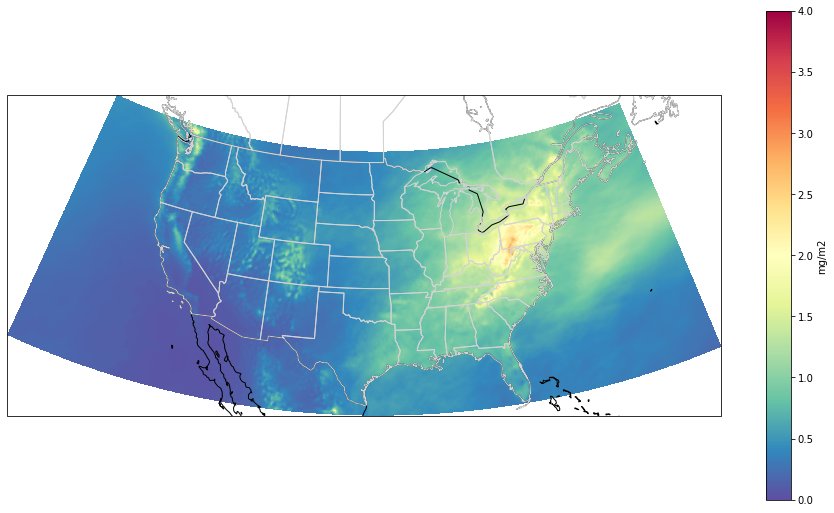

In [11]:
# CONUS MAP To put data on a traditional fixed-grid we are using griddata
#this will define the lat/lon range we are using to correspond to 0.1x0.1 over CONUS
x = np.linspace(225,300,751) #was 225
y =  np.linspace(25,50,501)

#this will put lat and lon into arrays, something that is needed for plotting
X, Y = np.meshgrid(x,y)

#here we are putting the unstructured data onto our defined 0.1x0.1 grid using linear interpolation
grid_var = griddata((lon,lat), var_mus, (X, Y), method='linear')

fig, ax = plot_map_LCC(grid_var,Y,X,0, 4,'mg/m2')
